In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

In [2]:
import pandas as pd

from pathlib import Path

from models.pytorch.model import PyTorchModel

project_root = Path().resolve().parents[1]


In [3]:
model_path = project_root / "models" / "pytorch-dnn.pt"
model = PyTorchModel.load(model_path)

In [4]:
dataset_path = project_root / "src" / "data" / "subm1_labels_revealed.csv"

df = pd.read_csv(dataset_path, sep=";")

In [5]:
X = df["Text"].tolist()
y = df["Label"].tolist()

predicted_labels = model.predict(X, y)

df["Labels"] = predicted_labels

Accuracy: 83/100 (83.00%)


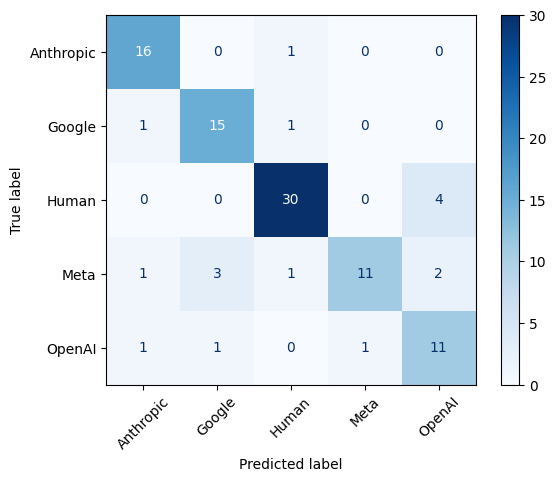

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.label_map.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

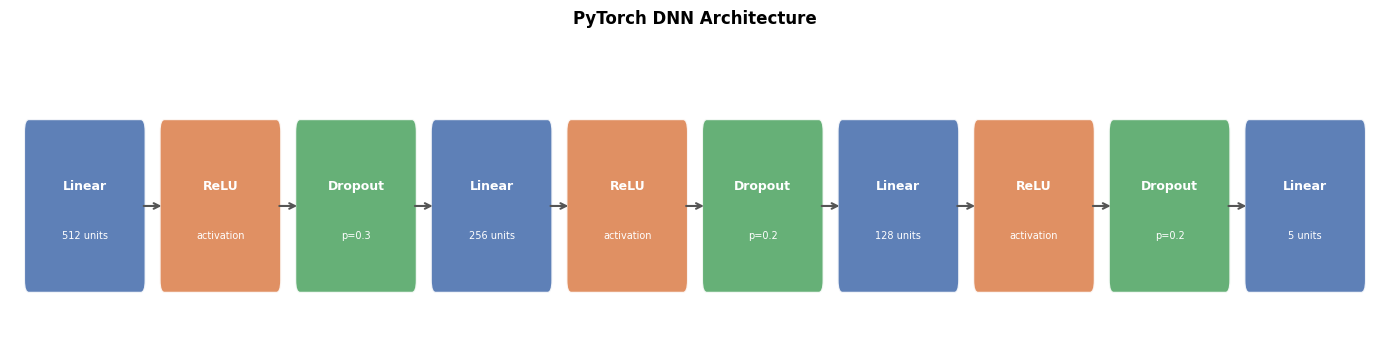

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layers = []
for layer in model.model.net:
    if isinstance(layer, __import__("torch").nn.Linear):
        layers.append(("Linear", f"{layer.out_features} units", "#4C72B0"))
    elif isinstance(layer, __import__("torch").nn.ReLU):
        layers.append(("ReLU", "activation", "#DD8452"))
    elif isinstance(layer, __import__("torch").nn.Dropout):
        layers.append(("Dropout", f"p={layer.p}", "#55A868"))
    else:
        layers.append((type(layer).__name__, "", "#8C8C8C"))

fig, ax = plt.subplots(figsize=(max(8, len(layers) * 1.4), 3.5))
ax.axis("off")

box_w, box_h, gap = 1.2, 0.6, 0.25
total_w = len(layers) * (box_w + gap) - gap

for i, (name, detail, color) in enumerate(layers):
    x = i * (box_w + gap)
    if i > 0:
        ax.annotate(
            "",
            xy=(x, box_h / 2),
            xytext=(x - gap, box_h / 2),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.5),
        )

    rect = mpatches.FancyBboxPatch(
        (x, 0),
        box_w,
        box_h,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.9,
    )
    ax.add_patch(rect)
    ax.text(x + box_w / 2, box_h / 2 + 0.08, name,
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    ax.text(x + box_w / 2, box_h / 2 - 0.12, detail,
            ha="center", va="center", fontsize=7, color="white")

ax.set_xlim(-0.2, total_w + 0.2)
ax.set_ylim(-0.2, 1.0)
ax.set_title("PyTorch DNN Architecture", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


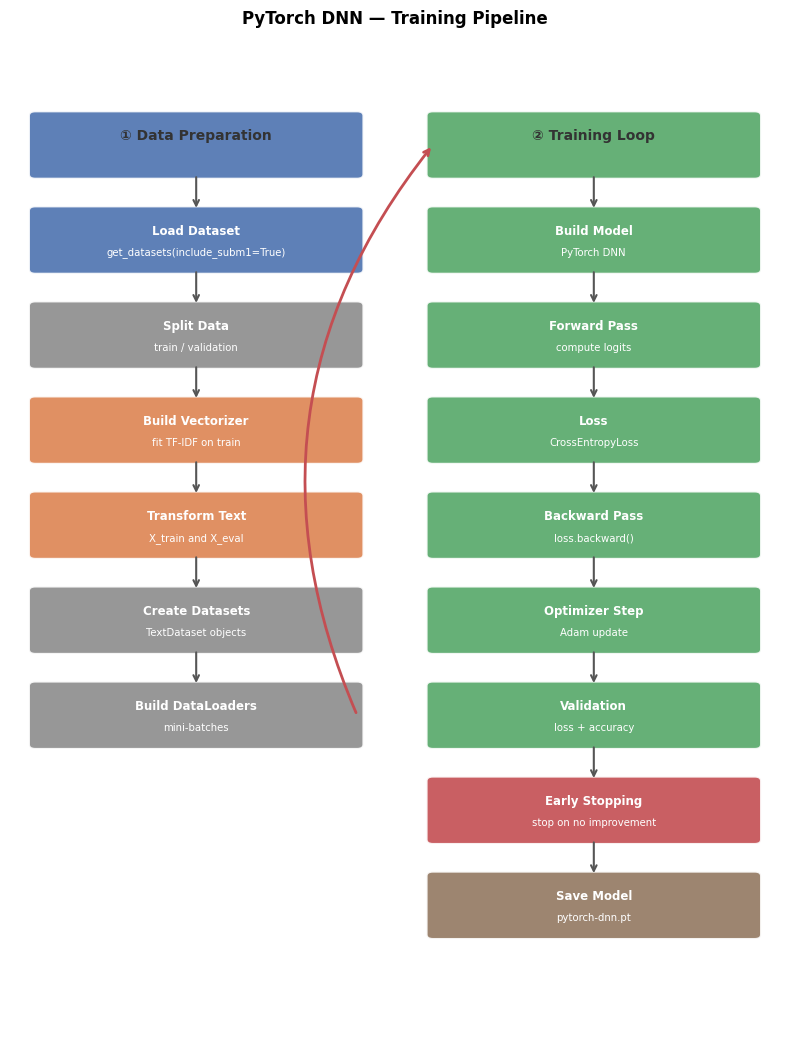

In [8]:
from models.pytorch.train import PyTorchTrainer

# Visual representation of the PyTorch training pipeline
PyTorchTrainer.plot_pipeline()